In [116]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess

from utils import compose_windows, make_names_dict, print_timestamp

import statsmodels.api as sm

from sklearn.base import clone
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score

In [158]:
def num_features_from_epv(tissue: str, epv: int = 10) -> int:
    """
    Compute the number of events and the optimal number of features to obtain the desired EPV

    events per variable:
    EPV = number_of_events / number_of_features 
    (events == positive class)
    """

    training_data_dir = "results/training_data/unfiltered/"
    
    windows = ["06-08", "10-12", "14-16"] # paths formatting
    timepoints = ["6-8h", "10-12h", "14-16h"] # columns fomratting


    y_vector = []
    for w, tp in zip(windows, timepoints):
        curr_path = os.path.join(training_data_dir, f"hrs{w}/y_{tissue}.csv")
        curr_df = pd.read_csv(curr_path)
        
        y_vector.extend(curr_df[f"Dmel_{tp}_{tissue}"].to_list())

    num_events = sum(y_vector)

    return int(np.ceil(num_events / epv))

def downsample_features(tissue: str, num_features = None) -> pd.Series:
    shap_importance = pd.read_csv(f"results/shap/XGB/{tissue}_shap_table_XGB.csv")

    # Sortuję po abs_mean_importance
    # Sortowanie po mean_abs_importance daje wyraźnie inne wyniki, ale bardzo podobne 
    # do takich jakbyśmy dostali biorąc motywy o największym odchyleniu standardowym importance
    
    sorted_features = shap_importance.sort_values('abs_mean_importance', ascending=False)["motif_id"]
    
    if num_features:
        return sorted_features[:num_features]
    else:
        return sorted_features

In [ ]:
downsampled_features[]

Series([], Name: motif_id, dtype: object)

In [159]:
def compose_downsampled_windows(tissue: str, downsampled_features: pd.Series, windows:list[str] = ["06-08", "10-12", "14-16"]) -> tuple:
    """
    TIME-AGNOSTIC CLASSIFIER
    concatenate window-specific DataFrames and generate a `composite` vector for stratification
    
    Extract top n features based on a previous shap analysis
    """
    Xs, ys = [], []
    training_dir = "results/training_data/unfiltered"
    
    for idx, w in enumerate(windows):

        curr_X = pd.read_csv(os.path.join(training_dir, f"hrs{w}/motif_enrichment_hrs{w}.csv"), index_col=0)
        curr_y = pd.read_csv(os.path.join(training_dir, f"hrs{w}/y_{tissue}.csv"), index_col=0).iloc[:, 0]
        
        curr_X = curr_X.dropna(axis=0)
        curr_X = curr_X[downsampled_features] # crucial change
        
        curr_X['window'] = idx

        # align X and y
        common_index = curr_X.index.intersection(curr_y.index)
        curr_X = curr_X.loc[common_index]
        curr_y = curr_y.loc[common_index]

        Xs.append(curr_X)
        ys.append(curr_y)

    y_new = pd.concat(ys, axis=0)
    X_new = pd.concat(Xs, axis=0)

    composite = pd.Categorical(list(zip(X_new['window'], y_new))).codes
    num_values = len(pd.Series(composite).unique())
    # print(f"Created a composite vector with {num_values} distinct values")

    X_new.drop('window', axis=1, inplace=True) # we don't want to use 'window' for prediction

    return X_new, y_new, composite

In [111]:
tissue = "Neurons"
epv = 10


num_features = num_features_from_epv(tissue, epv)
downsampled_features = downsample_features(tissue, num_features)

X, y, composite = compose_downsampled_windows(tissue, downsampled_features)

## TODO (z 13.01.26 chyba)

Zrobić to w statsmodels, tak jak opisano na Mattermost. W statsmodels trzeba ręczenie dodać wyraz wolny w modelu liniowym.

Dodać do df informacje o wagach i zapisać to w postaci long

Narysować współczynninki z regresji logistycznej z przedziałami ufności

### Logistic Regression regularization trajecotries:

Here we only investigate what happens to the model weights as we turn up the L2. L1 and ElasticNet are ignored only for simplicity and no other reason.

For each tissue, a DataFrame is created that contains:

2. Lists of most important motifs based on weights of the model **trained on all of the data**

----
## Plan życia (po naprawieniu problemu z osobliwością)

1. zrobić klasyfikator tak, żeby faktycznie istniał
    - wypisać wszystkie kolumny liniowo zależne i nazwać te motywy
    - zinterpretować dziwne wyniki z tego klasyfikatora, który udało się wytrenować (z regularyzacją). MLE, który nie ma convergence (!)

2. Zapisać tę formę long i dodać do niej informacje o wagach
    - dlaczego wide nie jest dobre? (wiedziałem to)

3. Narysować współczynniki z regresji z przedziałami ufności (?)
    - do tego z jakiegoś powodu powinien być klasyfikator bez regularyzacji... bo L1 nie jest różniczkowalne?
----

## Plan życia nowy (ale zgodny z tym poprzednim)

1. Zobaczyć czemu wychodzi osobliwość
    - może wywalić te współliniowe kolumny? (Zachłannie, albo po motif importance z shap)
2. Ewentualnie downsamplować cechy po istotnościach (np. wziąć górne 120, wtedy events per variable == 10)

----

In [79]:
windows=["06-08", "10-12", "14-16"]
tissues=["Neuroblasts", "Neurons", "Glia"]
model_name = "Logistic Regression"
model_short = "LR"

n_splits = 10   # cross-validation splits

alpha_values = np.array([0, 0.01, 0.1, 0.2, 0.5, 1, 2, 10]) # values for the regularization strength

### Singular matrix wyskakuje tylko dla Neuronów bez regularyzacji
- pozostałe mają ten ConvergenceWarning (nie wszystkie)

### Update 24.03.26: teraz singular matrix wyskakuje tylko dla **Neuroblastów** bez regularyzacji
- Wszystkie regularyzacje (na pełnych cechach) mają problem z regularyzacją

In [171]:
# to jest test 

epv = 5
tissue = "Neuroblasts"
motif_annotations_path = "data/motif_names.tsv"

num_features = 170#num_features_from_epv(tissue, epv)
print_timestamp(f"Selected {num_features} features for tissue {tissue} and epv = {epv}")

downsampled_features = downsample_features(tissue, num_features)

X, y, composite = compose_downsampled_windows(tissue, downsampled_features)
# Load windows
# X, y, composite = compose_windows(tissue)

results = []


# Load motif annotations
annot = pd.read_csv(motif_annotations_path, sep="\t")

code_to_name = (
    annot
    .drop_duplicates("id")
    .set_index("id")["name"]
    .astype(str)
    .to_dict()
)

for name, id in code_to_name.items():
    code_to_name[name] = str(name) + "  -  (" + str(id) + ")"


mapped_columns = (
    X.columns
    .to_series()
    .map(code_to_name)
    .fillna(pd.Series(X.columns, index=X.columns))
)

X_named = X.copy()
X_named.columns = mapped_columns

# Final fit on full data
X_full_sm = sm.add_constant(X_named)
model_full = sm.Logit(y, X_full_sm)

alpha = 0.3

# Regularized fit for weights
if alpha == 0.0:
    res_reg = model_full.fit(disp=False)
else:
    res_reg = model_full.fit_regularized(
        alpha=alpha,
        method='l1',
        #L1_wt=0.0,  # ten parametr nie istnieje w dokumentacji!
        disp=False
    )


2026-03-24 23:33:28 Selected 170 features for tissue Neuroblasts and epv = 5


KeyboardInterrupt: 

In [144]:
import numpy as np
import pandas as pd

# Summary table
summary_df = pd.DataFrame({
    "coef": res_reg.params,
    "std_err": res_reg.bse,
    "z": res_reg.tvalues,
    "p": res_reg.pvalues
})

# Confidence intervals
ci = res_reg.conf_int()
ci.columns = ["ci_lower", "ci_upper"]

summary_df = pd.concat([summary_df, ci], axis=1)

# Odds ratios
summary_df["odds_ratio"] = np.exp(summary_df["coef"])
summary_df["or_lower"] = np.exp(summary_df["ci_lower"])
summary_df["or_upper"] = np.exp(summary_df["ci_upper"])

# Sort by importance
summary_df = summary_df.sort_values("coef", key=abs, ascending=False)

In [145]:
summary_df

,coef,std_err,z,p,ci_lower,ci_upper,odds_ratio,or_lower,or_upper
M4720-1.02 - (abd-A),-8.880865,3.701416,-2.399315,0.016426,-16.135508,-1.626222,0.000139,9.827388e-08,0.196671
M5102-1.02 - (Med),-7.440341,2.895464,-2.569654,0.010180,-13.115346,-1.765336,0.000587,2.014084e-06,0.171129
M4873-1.02 - (CG6276),7.397568,2.674547,2.765914,0.005676,2.155552,12.639583,1632.009757,8.632653e+00,308532.724414
M5047-1.02 - (jigr1),-7.263725,2.482484,-2.925990,0.003434,-12.129305,-2.398145,0.000700,5.398954e-06,0.090886
M4747-1.02 - (Atf-2),-6.679656,2.534685,-2.635300,0.008406,-11.647548,-1.711765,0.001256,8.740460e-06,0.180547
...,...,...,...,...,...,...,...,...,...
M5103-1.02 - (Mes2),0.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
M1090-1.02 - (ems),0.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
M5203-1.02 - (sob),0.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
M4787-1.02 - (byn),0.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


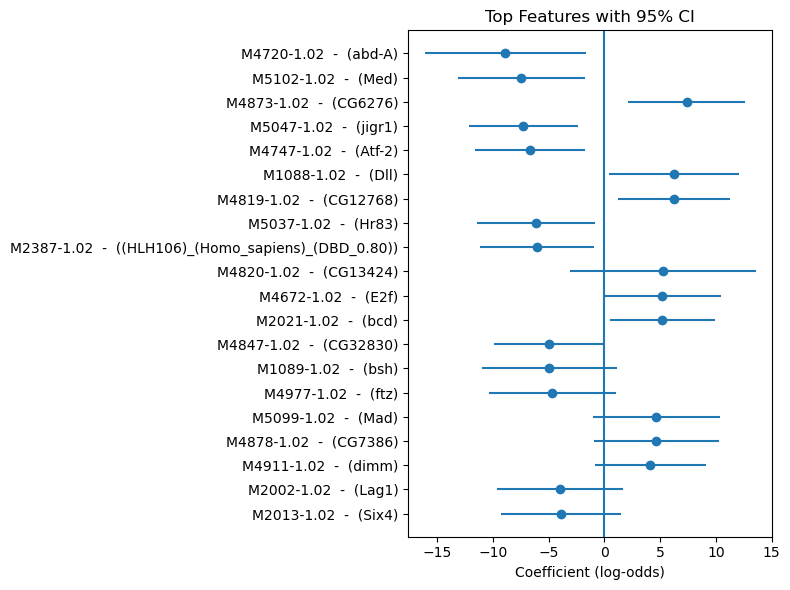

In [146]:
import matplotlib.pyplot as plt

top_n = 20
df_plot = summary_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 6))

plt.errorbar(
    df_plot["coef"],
    df_plot.index,
    xerr=[
        df_plot["coef"] - df_plot["ci_lower"],
        df_plot["ci_upper"] - df_plot["coef"]
    ],
    fmt='o'
)

plt.axvline(0)
plt.xlabel("Coefficient (log-odds)")
plt.title("Top Features with 95% CI")
plt.tight_layout()
plt.show()

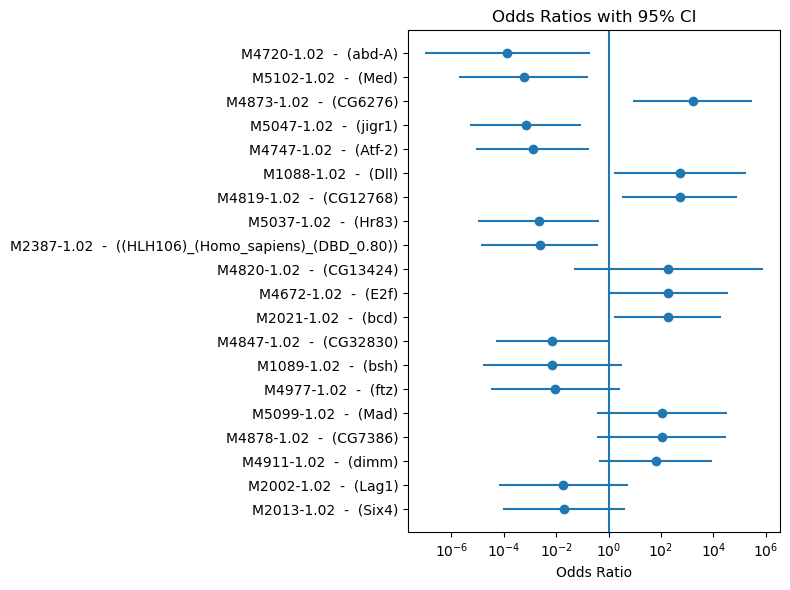

In [147]:
df_plot = summary_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 6))

plt.errorbar(
    df_plot["odds_ratio"],
    df_plot.index,
    xerr=[
        df_plot["odds_ratio"] - df_plot["or_lower"],
        df_plot["or_upper"] - df_plot["odds_ratio"]
    ],
    fmt='o'
)

plt.axvline(1)  # neutral effect
plt.xlabel("Odds Ratio")
plt.title("Odds Ratios with 95% CI")
plt.xscale("log")
plt.tight_layout()
plt.show()

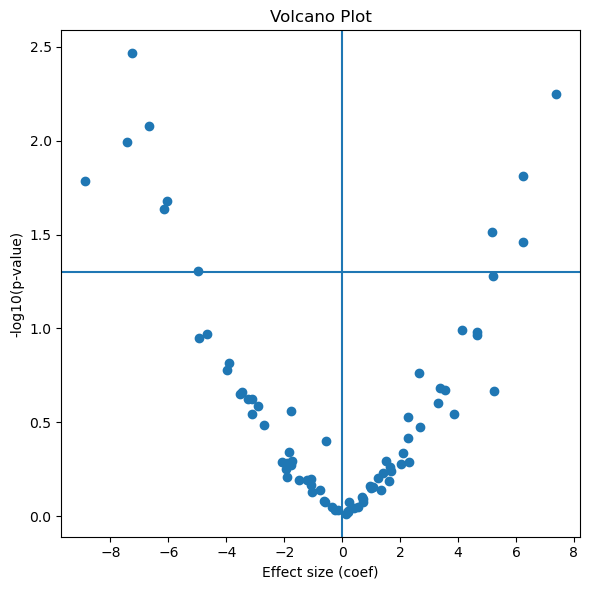

In [148]:
plt.figure(figsize=(6, 6))

plt.scatter(
    summary_df["coef"],
    -np.log10(summary_df["p"])
)

plt.axhline(-np.log10(0.05))
plt.axvline(0)

plt.xlabel("Effect size (coef)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot")

plt.tight_layout()
plt.show()

## Szukanie kolumn liniowo zależnych

In [ ]:
# from sklearn.feature_selection import VarianceThreshold
# selector = VarianceThreshold(threshold=1e-5)
# X_reduced = selector.fit_transform(X_scaled)
# np.linalg.matrix_rank(X_reduced)

In [6]:
full_rank = np.linalg.matrix_rank(X)
colinear_names = []

for col_name in X.columns:

    X_curr = X.drop(columns=X.columns[col_idx])
    # print(X_curr.shape)
    # pd.concat((X.iloc[:,:col_idx], X.iloc[:,col_idx:]), axis=1)
    
    curr_rank = np.linalg.matrix_rank(X_curr)
    if curr_rank == full_rank:
        X
        colinear_names.append(X_curr.columns[col_idx])

colinear_names

NameError: name 'col_idx' is not defined

In [ ]:
# tutaj będą konkretne zbiory motywów zależnych od siebie nawzajem parami

def find_colinear_motifs():
    colinear_names = []
    return colinear_names   